https://drive.google.com/file/d/1XtaKeD7b-la2R1ygFBNLj16VD1k0MB2Q/view?usp=drive_link

In [1]:
import pandas as pd
!gdown --id '1XtaKeD7b-la2R1ygFBNLj16VD1k0MB2Q'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1XtaKeD7b-la2R1ygFBNLj16VD1k0MB2Q
To: /content/clusteringmidterm.csv
100% 1.01M/1.01M [00:00<00:00, 72.4MB/s]


In [2]:
df = pd.read_csv('clusteringmidterm.csv')

### Dataset Check

In [3]:
df.shape

(8950, 18)

In [4]:
df.head(2)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


### Import library

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

### EDA singkat

Cek distribusi, missing values, dan outlier sebelum preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
# check missing
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [8]:
# check statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


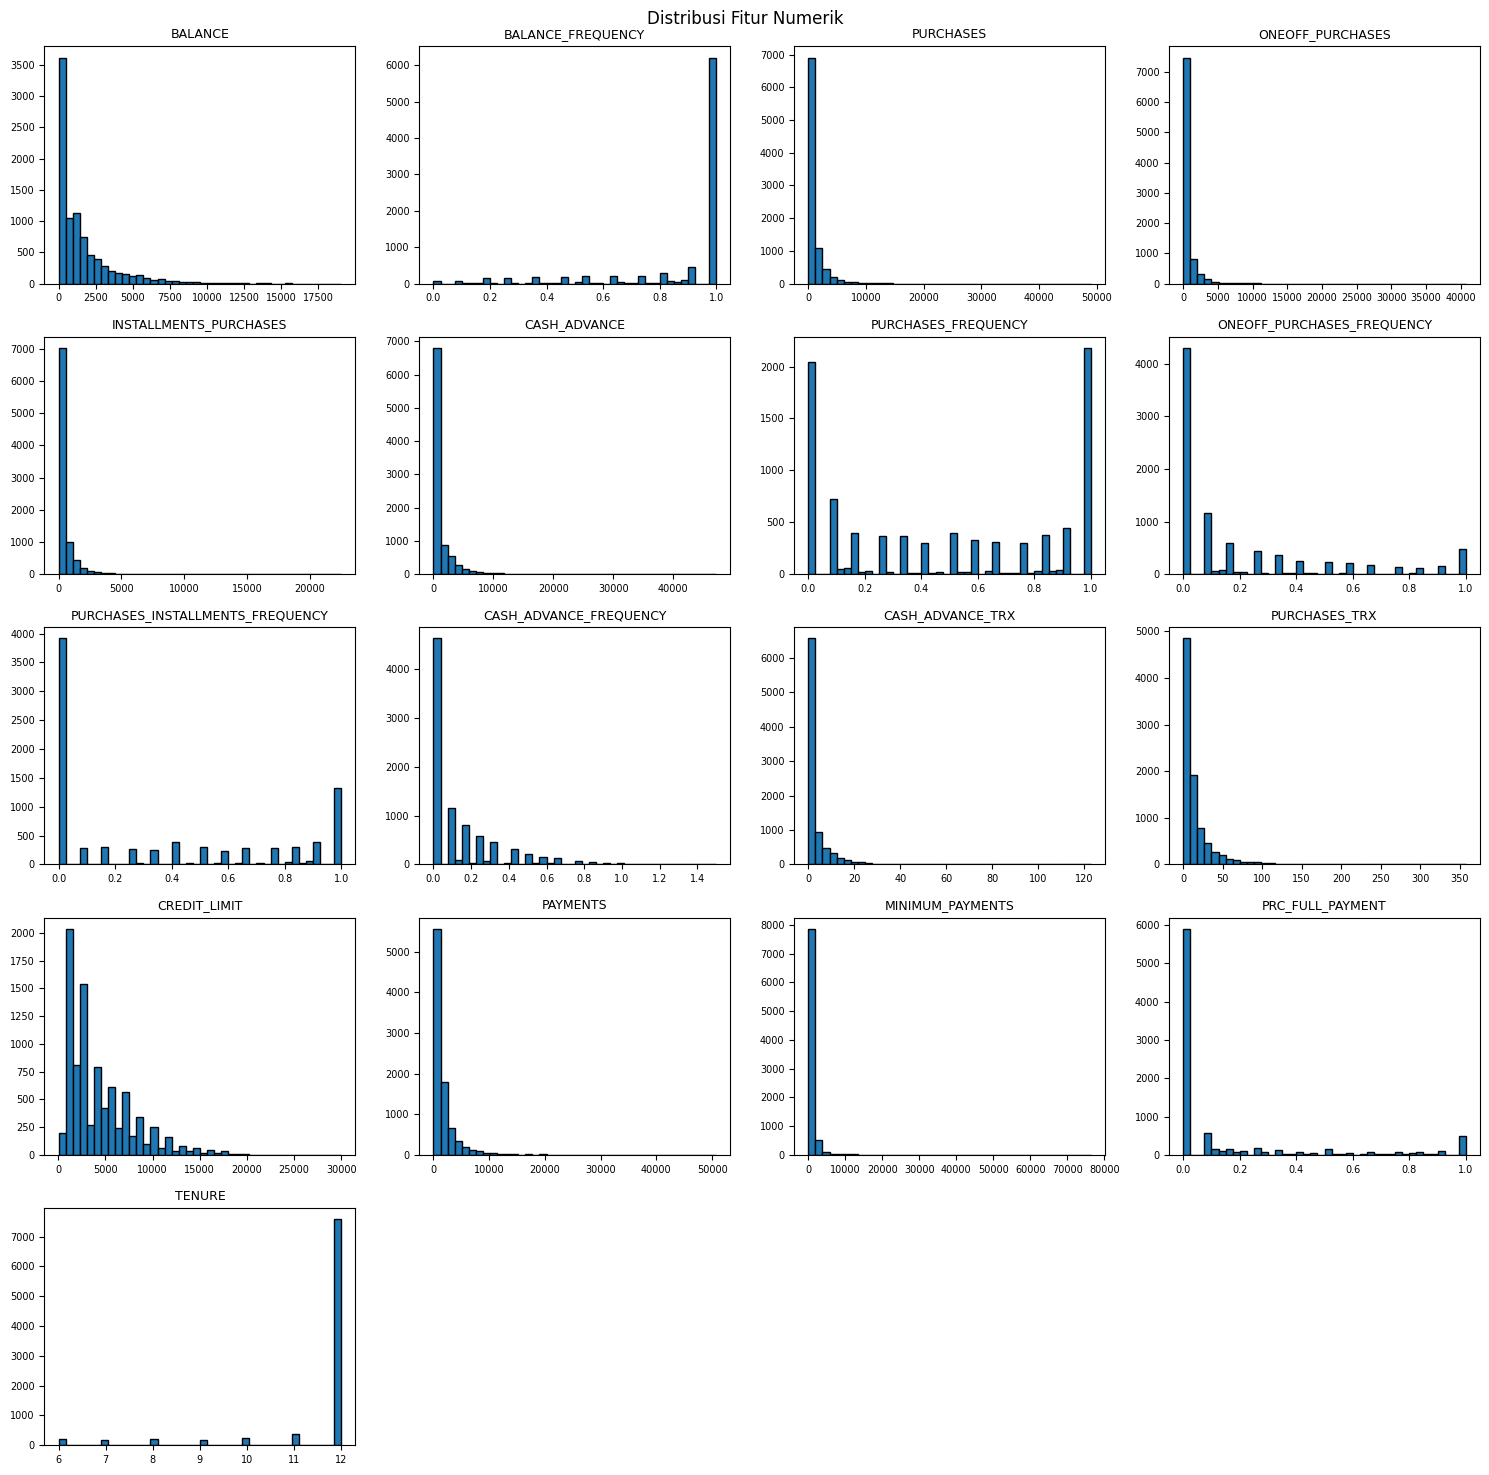

In [13]:
import math

num_cols = df.select_dtypes(include=np.number).columns.tolist()
n_cols = 4  # mau 4 kolom per baris
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  axes[i].hist(df[col].dropna(), bins=40, edgecolor='k')
  axes[i].set_title(col, fontsize=9)
  axes[i].tick_params(labelsize=7)

# Hapus subplot kosong (kalau ada)
for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=12)
plt.tight_layout()
plt.savefig('distributions.png', dpi=80, bbox_inches='tight')
plt.show()

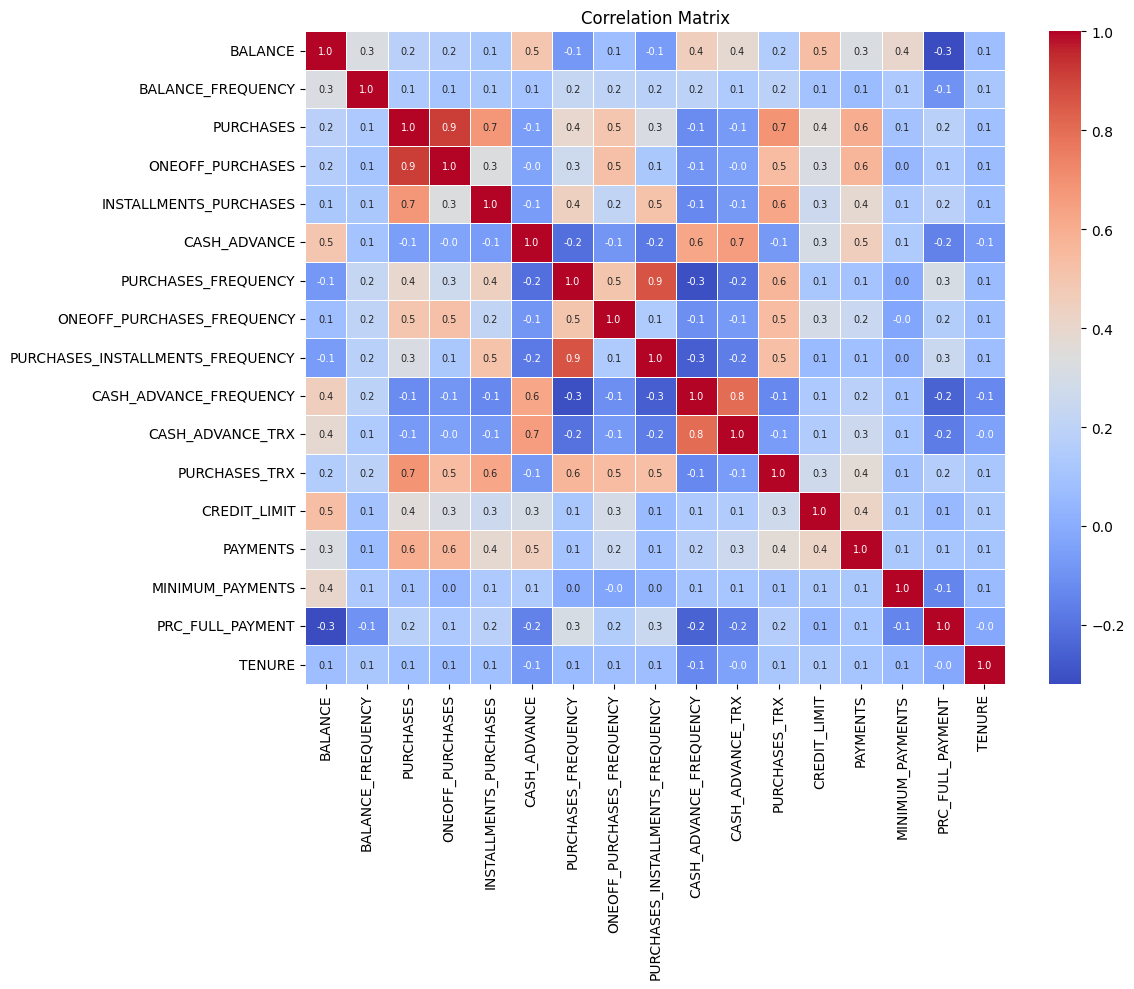

In [14]:
# Heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation.png', dpi=80)
plt.show()

### Preprocessing

PREPROCESSING
1. Drop CUST_ID (ID bukan fitur)
2. Imputasi missing value dengan median (robust terhadap outlier)
3. Standardisasi (wajib untuk distance-based clustering)

In [15]:
# drop kolom ID
df_clean = df.drop(columns=['CUST_ID'])

In [16]:
# Imputasi median — MINIMUM_PAYMENTS dan CREDIT_LIMIT ada missing
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_clean)

In [17]:
# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [18]:
print(f"Shape setelah preprocessing: {X_scaled.shape}")
print(f"Missing values tersisa: {np.isnan(X_scaled).sum()}")

Shape setelah preprocessing: (8950, 17)
Missing values tersisa: 0


### PCA untuk Reduksi Dimensi

Dataset 17 fitur → reduksi ke komponen yang jelaskan 90% variance
Ini KRUSIAL supaya clustering lebih cepat & hasil lebih bersih

In [19]:
pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

In [20]:
# Kumulatif explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.90) + 1
print(f"Komponen untuk 90% variance: {n_components}")

Komponen untuk 90% variance: 10


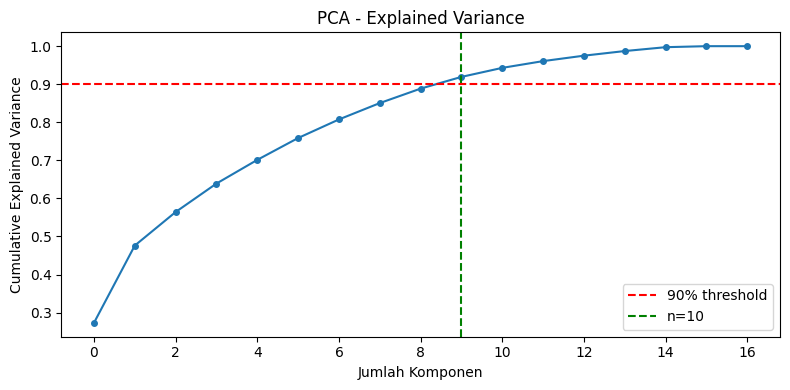

In [21]:
# Plot explained variance
plt.figure(figsize=(8, 4))
plt.plot(cumvar, marker='o', markersize=4)
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.axvline(n_components - 1, color='g', linestyle='--', label=f'n={n_components}')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Terapkan PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Shape setelah PCA: {X_pca.shape}")

Shape setelah PCA: (8950, 10)


###  Elbow Method untuk K-Means

Cari optimal K untuk KMeans
Range 2-10 cukup, lebih dari itu overfitting cluster

In [23]:
inertias = []
sil_scores = []
K_range = range(2, 11)

In [24]:
for k in K_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(X_pca)
  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X_pca, labels))
  print(f"K={k} | Inertia={km.inertia_:.0f} | Silhouette={sil_scores[-1]:.4f}")

K=2 | Inertia=115532 | Silhouette=0.2242
K=3 | Inertia=99805 | Silhouette=0.2586
K=4 | Inertia=86972 | Silhouette=0.2169
K=5 | Inertia=79582 | Silhouette=0.2118
K=6 | Inertia=72945 | Silhouette=0.2241
K=7 | Inertia=68261 | Silhouette=0.2289
K=8 | Inertia=63002 | Silhouette=0.2444
K=9 | Inertia=58471 | Silhouette=0.2486
K=10 | Inertia=55312 | Silhouette=0.2410


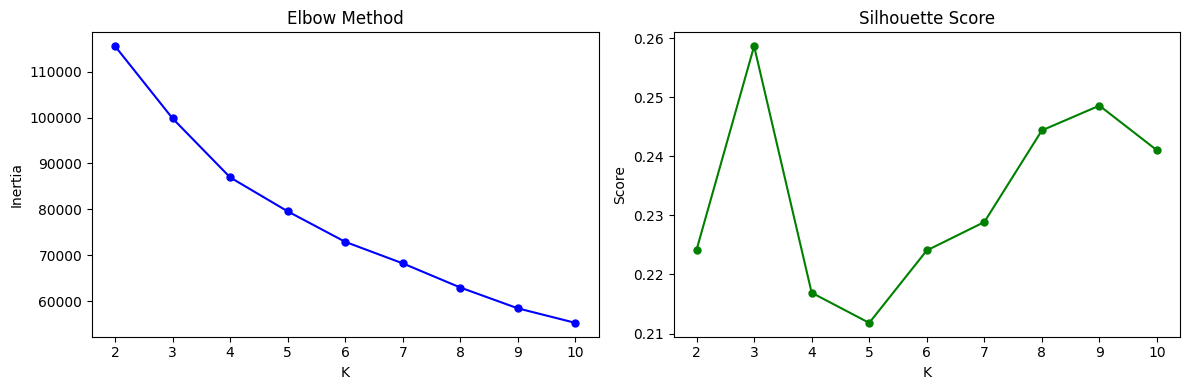

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-', markersize=5)
ax1.set_title('Elbow Method')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, 'go-', markersize=5)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()


In [29]:
best_k = K_range[np.argmax(sil_scores)]
print(f"\nOptimal K berdasarkan Silhouette: {best_k}")


Optimal K berdasarkan Silhouette: 3


### Train 3 Model Clustering

1. KMeans         — baseline, cepat, asumsi cluster bulat
2. Agglomerative  — hierarchical, ga perlu K optimal duluan
3. DBSCAN         — density-based, bisa detect noise/outlier

In [30]:
results = {}

In [31]:
# --- 1. KMeans ---
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = km.fit_predict(X_pca)
results['KMeans'] = labels_km

In [32]:
# --- 2. Agglomerative Clustering ---
agg = AgglomerativeClustering(n_clusters=best_k)
labels_agg = agg.fit_predict(X_pca)
results['Agglomerative'] = labels_agg

In [33]:
# --- 3. DBSCAN (eps dan min_samples perlu tuning) ---
# eps=1.5 dan min_samples=5 adalah starting point umum untuk data terstandarisasi
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f"DBSCAN: {n_clusters_db} cluster, {n_noise} noise points ({n_noise/len(labels_db)*100:.1f}%)")
results['DBSCAN'] = labels_db

DBSCAN: 4 cluster, 773 noise points (8.6%)


### Evaluasi

1. Silhouette Score  : makin tinggi makin baik (-1 sampai 1)
2. Davies-Bouldin    : makin RENDAH makin baik (>=0)
3. Calinski-Harabasz : makin tinggi makin baik
4. DBSCAN dikecualikan dari CH/DB kalau ada noise point banyak

In [34]:
metrics = {}
for name, labels in results.items():
  # Filter noise untuk DBSCAN (label = -1)
  mask = labels != -1
  if mask.sum() < 2 or len(set(labels[mask])) < 2:
    print(f"{name}: tidak cukup cluster valid untuk dievaluasi")
    continue
  sil = silhouette_score(X_pca[mask], labels[mask])
  db  = davies_bouldin_score(X_pca[mask], labels[mask])
  ch  = calinski_harabasz_score(X_pca[mask], labels[mask])
  metrics[name] = {'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch}
  print(f"{name:15} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.2f}")

KMeans          | Silhouette=0.2586 | DB=1.4980 | CH=1795.89
Agglomerative   | Silhouette=0.2512 | DB=1.5663 | CH=1463.99
DBSCAN          | Silhouette=0.2338 | DB=0.6567 | CH=18.44


In [35]:
# Tabel ringkasan
metrics_df = pd.DataFrame(metrics).T
print("\n=== SUMMARY ===")
print(metrics_df.to_string())


=== SUMMARY ===
               Silhouette  Davies-Bouldin  Calinski-Harabasz
KMeans           0.258645        1.498041        1795.887779
Agglomerative    0.251152        1.566344        1463.985184
DBSCAN           0.233775        0.656667          18.441823


### Interpretasi

Pakai model terbaik (biasanya KMeans atau Agglomerative), kembalikan ke skala asli supaya bisa dibaca manusia

In [36]:
# Pakai label dari model terbaik berdasarkan evaluasi
best_model_name = max(metrics, key=lambda x: metrics[x]['Silhouette'])
print(f"Model terbaik: {best_model_name}")
best_labels = results[best_model_name]

Model terbaik: KMeans


In [37]:
# Buat dataframe dengan label cluster
df_profile = df_clean.copy()
# Imputasi dulu (supaya ga ada NaN)
df_profile_imp = pd.DataFrame(imputer.transform(df_profile), columns=df_clean.columns)
df_profile_imp['Cluster'] = best_labels

In [38]:
# Filter noise kalau DBSCAN
df_profile_imp = df_profile_imp[df_profile_imp['Cluster'] != -1]

In [39]:
# Rata-rata tiap cluster
cluster_summary = df_profile_imp.groupby('Cluster').mean().T
print("Rata-rata per CLUSTER")
print(cluster_summary.to_string())

Rata-rata per CLUSTER
Cluster                                     0            1            2
BALANCE                            798.703861  3973.741175  2224.159102
BALANCE_FREQUENCY                    0.835097     0.957676     0.980996
PURCHASES                          503.377955   379.069706  4265.429541
ONEOFF_PURCHASES                   250.936447   245.352736  2719.030483
INSTALLMENTS_PURCHASES             252.762936   133.794216  1546.882150
CASH_ADVANCE                       327.567421  3866.289041   459.350616
PURCHASES_FREQUENCY                  0.465481     0.230794     0.947214
ONEOFF_PURCHASES_FREQUENCY           0.132144     0.110867     0.666260
PURCHASES_INSTALLMENTS_FREQUENCY     0.345891     0.142647     0.741528
CASH_ADVANCE_FREQUENCY               0.068251     0.446120     0.063201
CASH_ADVANCE_TRX                     1.205666    12.372892     1.533816
PURCHASES_TRX                        8.658097     5.578389    56.237520
CREDIT_LIMIT                      3264.479

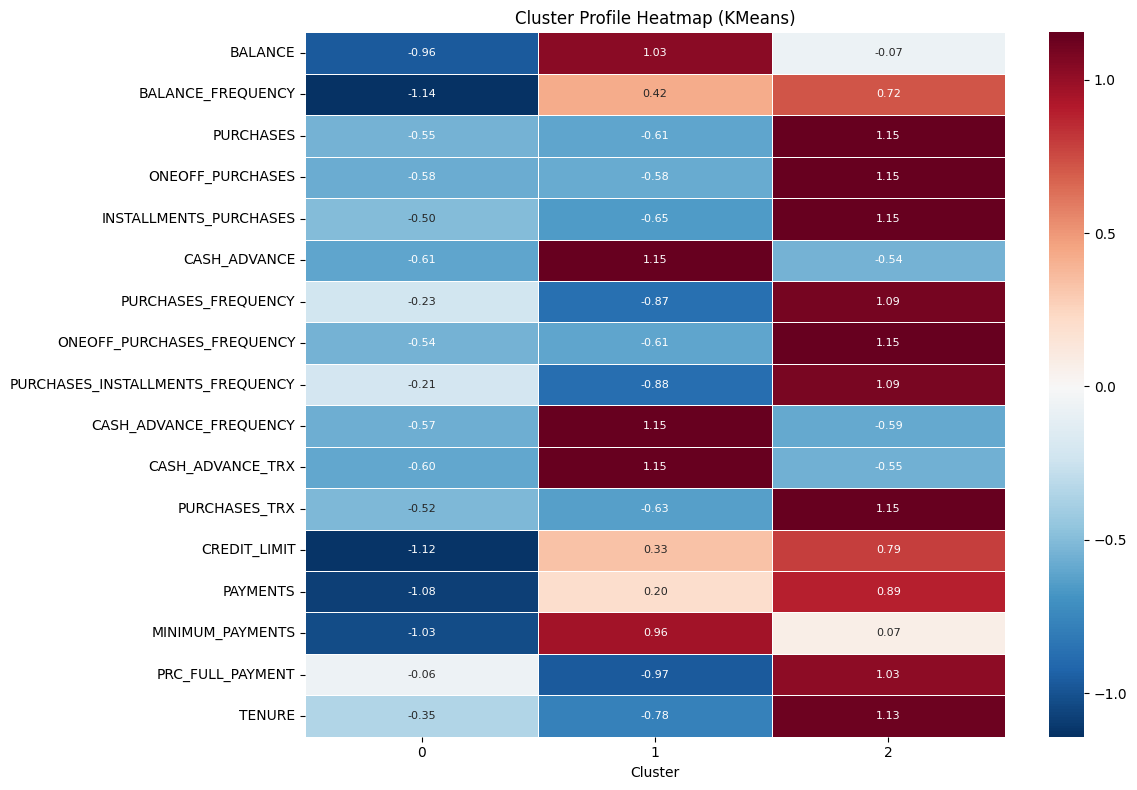

In [40]:
# Visualisasi profil cluster dengan heatmap
plt.figure(figsize=(12, 8))
# Standarisasi untuk heatmap supaya skala comparable
summary_std = (cluster_summary - cluster_summary.mean(axis=1).values.reshape(-1,1)) / \
              (cluster_summary.std(axis=1).values.reshape(-1,1) + 1e-8)
sns.heatmap(summary_std, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, annot_kws={'size':8})
plt.title(f'Cluster Profile Heatmap ({best_model_name})')
plt.tight_layout()
plt.savefig('cluster_profile.png', dpi=80)
plt.show()

### Kesimpulan

In [41]:
print(f"Dataset   : {df.shape[0]} customers, {df.shape[1]-1} fitur")
print(f"PCA       : {n_components} komponen (90% variance)")
print(f"Optimal K : {best_k} (berdasarkan Silhouette Score)")

Dataset   : 8950 customers, 17 fitur
PCA       : 10 komponen (90% variance)
Optimal K : 3 (berdasarkan Silhouette Score)


In [42]:
print(f"Evaluasi Model:")
print(metrics_df.to_string())
print(f"Model terbaik : {best_model_name}")

Evaluasi Model:
               Silhouette  Davies-Bouldin  Calinski-Harabasz
KMeans           0.258645        1.498041        1795.887779
Agglomerative    0.251152        1.566344        1463.985184
DBSCAN           0.233775        0.656667          18.441823
Model terbaik : KMeans


In [43]:
print("DISTRIBUSI CLUSTER")
unique, counts = np.unique(best_labels[best_labels != -1], return_counts=True)
for u, c in zip(unique, counts):
  print(f"Cluster {u}: {c} customers ({c/len(best_labels)*100:.1f}%)")

DISTRIBUSI CLUSTER
Cluster 0: 6107 customers (68.2%)
Cluster 1: 1601 customers (17.9%)
Cluster 2: 1242 customers (13.9%)


In [45]:
print("""
--- INTERPRETASI BISNIS ---
Cluster 0 → 'Dormant Low-Value Customers' (68.2%)
  Nasabah pasif dengan utilisasi kartu rendah. Balance, purchases, dan
  pembayaran semuanya di bawah rata-rata. Credit limit kecil.
  Strategi: loyalty program atau cashback ringan untuk mendorong aktivasi.

Cluster 1 → 'Cash-Advance Dependent / High-Risk' (17.9%)
  Sangat bergantung pada cash advance (avg 3866, 12 transaksi).
  Jarang melunasi tagihan penuh (PRC_FULL_PAYMENT hanya 0.03).
  Minimum payment tinggi → indikasi debt cycling.
  Strategi: monitoring ketat, batasi cash advance, tawarkan debt restructuring.

Cluster 2 → 'Premium Active Spenders' (13.9%)
  Segmen paling profitable: purchases tertinggi (4265), transaksi 56x,
  credit limit tertinggi (7738), dan pembayaran paling besar (4144).
  PRC_FULL_PAYMENT 0.30 → relatif disiplin bayar.
  Strategi: reward premium, cross-sell produk investasi/asuransi, retensi VIP.
""")


--- INTERPRETASI BISNIS ---
Cluster 0 → 'Dormant Low-Value Customers' (68.2%)
  Nasabah pasif dengan utilisasi kartu rendah. Balance, purchases, dan
  pembayaran semuanya di bawah rata-rata. Credit limit kecil.
  Strategi: loyalty program atau cashback ringan untuk mendorong aktivasi.

Cluster 1 → 'Cash-Advance Dependent / High-Risk' (17.9%)
  Sangat bergantung pada cash advance (avg 3866, 12 transaksi).
  Jarang melunasi tagihan penuh (PRC_FULL_PAYMENT hanya 0.03).
  Minimum payment tinggi → indikasi debt cycling.
  Strategi: monitoring ketat, batasi cash advance, tawarkan debt restructuring.

Cluster 2 → 'Premium Active Spenders' (13.9%)
  Segmen paling profitable: purchases tertinggi (4265), transaksi 56x,
  credit limit tertinggi (7738), dan pembayaran paling besar (4144).
  PRC_FULL_PAYMENT 0.30 → relatif disiplin bayar.
  Strategi: reward premium, cross-sell produk investasi/asuransi, retensi VIP.

